In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
def cross_matrix(vec):
    return np.array([[0, -vec[2], vec[1]],
                      [vec[2], 0, -vec[0]],
                      [-vec[1], vec[0], 0]])

def uncross_matrix(mat):
    return np.array([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def omega_dot(t, omega, I_B):
    skew_omega= cross_matrix(omega)
    return -np.linalg.inv(I_B) @ (skew_omega @ I_B @ omega)
    

In [6]:
omega0 = np.array([0.1,0.9,0])
I_B = np.array([[10, 0, 0],
                [0,  5, 0],
                [0,  0, 1]], dtype=float)


time = np.linspace(0,10,1000)
sol = solve_ivp(lambda t, y: omega_dot(t,y,I_B),   # pass function, not its output
                [0,10], omega0,
                t_eval=time,
                atol=1e-8, rtol=1e-8)
omegadot_sol = sol.y


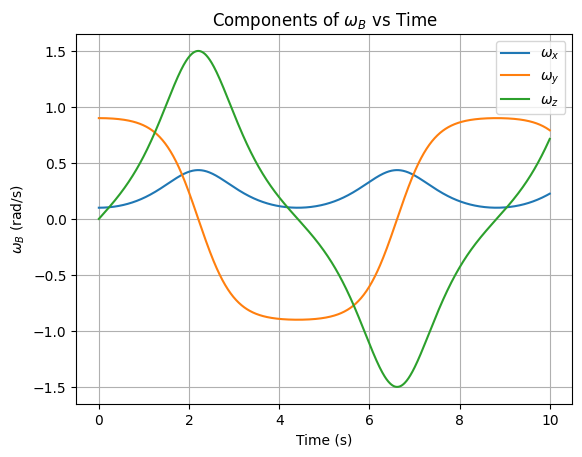

In [13]:
# --- Plot 1: omega components vs time ---
plt.figure(1)
plt.clf()
plt.plot(sol.t, omega_sol[0,:], label=r'$\omega_x$')
plt.plot(sol.t, omega_sol[1,:], label=r'$\omega_y$')
plt.plot(sol.t, omega_sol[2,:], label=r'$\omega_z$')
plt.xlabel('Time (s)')
plt.ylabel(r'$\omega_B$ (rad/s)')
plt.title(r'Components of $\omega_B$ vs Time')
plt.legend()
plt.grid(True)
plt.show()


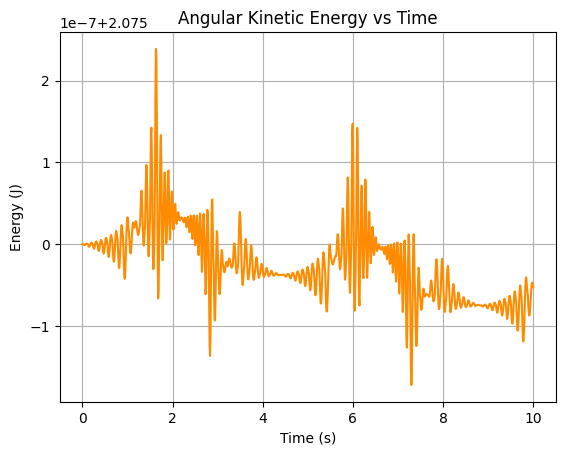

In [14]:
# --- Plot 2: Angular kinetic energy vs time ---
# T = 0.5 * omega^T @ I_B @ omega
T = 0.5 * np.einsum('ij,jk,ki->i', omega_sol.T, I_B, omega_sol)

plt.figure(2)
plt.clf()
plt.plot(sol.t, T, color='darkorange')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Angular Kinetic Energy vs Time')
plt.grid(True)
plt.show()

In [15]:
# Problem 3 Euler lagrange Simulation
import sympy as sp
from sympy import symbols, pprint, Function, simplify, Derivative, nsimplify
from sympy import sin, cos, asin, acos, pi, diff
from sympy import Matrix, latex, BlockMatrix, lambdify
import numpy as np

import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

from sympy import init_printing
init_printing() 

# Define Symbols
t = symbols("t" , real = True)
l0 = symbols("l0" , real = True)
m0 = symbols("m0" , real = True)
I0_xx = symbols("I0_xx" , real = True)
I0_yy = symbols("I0_yy" , real = True)
I0_zz = symbols("I0_zz" , real = True)
l1 = symbols("l1" , real = True)
m1 = symbols("m1" , real = True)
I1_xx = symbols("I1_xx" , real = True)
I1_yy = symbols("I1_yy" , real = True)
I1_zz = symbols("I1_zz" , real = True)
g = symbols("g" , real = True)
w = symbols("w",real=True)
theta_1 = Function('theta_1', real=True)(t)
theta_2 = Function('theta_2', real=True)(t)
x = Function('x', real=True)(t)
y = Function('y', real=True)(t)

In [16]:
# Defining Various Helper Functions
def cross_matrix(vec):
    
    return np.matrix([[0, -vec[2,0], vec[1,0]],
                      [vec[2,0], 0, -vec[0,0]],
                      [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    
    return np.matrix([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    
    return(m)
    
def R_z(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta), -sin(theta), 0], 
                   [sin(theta), cos(theta), 0],
                   [0, 0, 1]])

def R_y(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta),0, sin(theta)], 
                   [0, 1, 0],
                   [-sin(theta), 0, cos(theta)]])

def R_x(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta), cos(theta)]])
def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m

In [17]:
# T_world_to_body: translate to (x,y), rotate by theta
R01 = R_z(theta_1)           # theta is body angle
P01 = Matrix([[0], [0], [0]])
T01 = T(R01, P01)            # world -> center joint

# T_body_to_leg: no translation (leg attaches at same joint), rotate by phi
R12 = R_z(theta_2)           # phi is leg angle relative to body
P12 = Matrix([[x], [y], [0]])  # leg pivot is AT the center joint
T02 = T01 * T(R12, P12)      # world -> leg frame

In [ ]:
# m1 masses are at +w and -w along body link (horizontal in body frame)
p_m1_right = T01 * Matrix([[w], [0], [0], [1]])
p_m1_left  = T01 * Matrix([[-w], [0], [0], [1]])

# m2 is at tip of leg, distance l down the leg from center joint
p_m2 = T02 * Matrix([[0], [-l], [0], [1]])

# m1 mass Velocities
v_m1_right=diff(p_m1_right,t)
v_m1_left=diff(p_m1_left,t)
v_m2= diff(p_m2,t)

In [ ]:

T1 = 0.5 * np.einsum('ij,jk,ki->i', v_m1_right.T, I_B, v_m1_right)